# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [9]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [10]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [11]:
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        # define layers (Linear, BatchNorm1d, Dropout, etc.)
        self.net = nn.Sequential(
          nn.Linear(input_dim, h1),
          nn.BatchNorm1d(h1),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h1, h2),
          nn.BatchNorm1d(h2),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        # implement forward pass
        return self.net(x)

In [12]:
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4(input_dim = X_train_s1.shape[1], h1=16, h2=8, out_dim=4, p_drop=0.25).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)

In [13]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer.zero_grad()
            # forward pass
            logits = model(xb)
            # compute loss
            loss = loss_fn(logits, yb)
            # backward
            loss.backward()
            # optimizer step
            optimizer.step()

            # total += loss.item() * xb.size(0)
            total += loss.item() *xb.size(0)
            total_samples = xb.size(0)
            avg_loss = total / total_samples

        if ep in [1, epochs//2, epochs]:
            # print epoch + average loss
            print(f"Epoch {ep:3d} | average loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# Train the model
train_part1(model, train_loader_1)


Epoch   1 | average loss: 33.454189
Epoch 500 | average loss: 4.485928
Epoch 1000 | average loss: 4.493836


In [14]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8992    0.7690    0.8290      2377
           C     0.9924    0.9174    0.9534      2263
           B     0.9452    0.9653    0.9552      3057
           A     0.9781    0.9793    0.9787      3144

   micro avg     0.9557    0.9163    0.9356     10841
   macro avg     0.9537    0.9078    0.9291     10841
weighted avg     0.9545    0.9163    0.9340     10841
 samples avg     0.6610    0.6477    0.6486     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2920  205]
 [ 549 1828]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3223   16]
 [ 187 2076]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2274  171]
 [ 106 2951]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2289   69]
 [  65 3079]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8995    0.7556    0.8213      1019
           C     0.9845    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

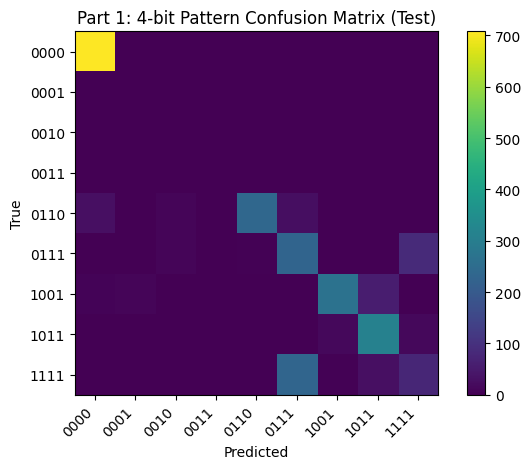

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 28   0  11   0 237  25   0   0   0]
 [  0   0  11   0   4 229   0   0  85]
 [  7   9   0   0   0   0 266  57   0]
 [  0   0   0   1   0   0  14 311  14]
 [  0   0   0   0   0 232   4  29  75]]


In [15]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [16]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [17]:
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        # define layers
        self.net = nn.Sequential(
          nn.Linear(input_dim, h1),
          nn.BatchNorm1d(h1),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h1, h2),
          nn.BatchNorm1d(h2),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        # forward pass returning logits (N,4)
        return self.net(x)


In [18]:
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiLabel4(input_dim = X_train_s2.shape[1], h1=16, h2=8, out_dim=4, p_drop=0.25)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)


In [19]:
# ----------------------------
# Training loop scaffold
# ----------------------------
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer.zero_grad()
            # logits = model(xb)
            logits = model(xb)
            # loss = loss_fn(logits, yb)
            loss = loss_fn(logits, yb)
            # backward + step
            loss.backward()
            optimizer.step()

            # total += loss.item() * xb.size(0)
            total += loss.item() * xb.size(0)
            total_samples = xb.size(0)
            avg_loss = total / total_samples

        if ep in [1, epochs//2, epochs]:
            # print epoch + average loss
            print(f"Epoch {ep:3d} | average loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

# Train the model
train_part2(model, train_loader_2)

Epoch   1 | average loss: 27.858639
Epoch 500 | average loss: 4.811301
Epoch 1000 | average loss: 4.700678


In [20]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6034      2377
           C     0.4266    1.0000    0.5980      2263
           B     0.5556    1.0000    0.7143      3057
           A     0.5714    1.0000    0.7273      3144

   micro avg     0.4970    1.0000    0.6640     10841
   macro avg     0.4964    1.0000    0.6608     10841
weighted avg     0.5062    1.0000    0.6695     10841
 samples avg     0.4986    0.6992    0.5730     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 3125]
 [   0 2377]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[ 197 3042]
 [   0 2263]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2445]
 [   0 3057]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2358]
 [   0 3144]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6033      1019
           C     0.4284    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


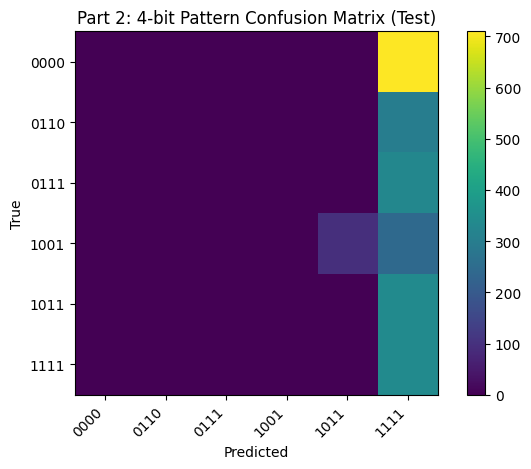

[[  0   0   0   0   0 710]
 [  0   0   0   0   0 301]
 [  0   0   0   0   0 329]
 [  0   0   0   0  95 244]
 [  0   0   0   0   0 340]
 [  0   0   0   0   0 340]]


In [21]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [22]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [23]:
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        # TODO: define layers
        self.net = nn.Sequential(
          nn.Linear(input_dim, h1),
          nn.BatchNorm1d(h1),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h1, h2),
          nn.BatchNorm1d(h2),
          nn.ReLU(),
          nn.Dropout(p_drop),

          nn.Linear(h2, num_classes)
        )

    def forward(self, x):
        # TODO: forward pass returning logits (N,6)
        return self.net(x)


In [24]:
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiClass6(input_dim = X_train_s3.shape[1], h1=16, h2=16, num_classes=6, p_drop=0.25)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)


In [25]:
# ----------------------------
# Training loop scaffold
# ----------------------------
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero
            optimizer.zero_grad()
            # logits = model(xb)
            logits = model(xb)
            # loss = loss_fn(logits, yb)
            loss = loss_fn(logits, yb)
            # backward + step
            loss.backward()
            optimizer.step()

            # total += loss.item() * xb.size(0)
            total += loss.item() * xb.size(0)
            total_samples = xb.size(0)
            avg_loss = total / total_samples

        if ep in [1, epochs//2, epochs]:
            # print epoch + average loss
            print(f"Epoch {ep:3d} | average loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

# Train the model
train_part3(model, train_loader_3)


Epoch   1 | average loss: 78.599221
Epoch 500 | average loss: 21.779077
Epoch 1000 | average loss: 21.297659



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9555    1.0000    0.9773      1655
          LG     0.8565    0.9519    0.9017       790
          LL     0.9024    0.9474    0.9244       703
         LLG     0.9467    0.8728    0.9083       794
         LLL     0.5161    0.8370    0.6385       767
        LLLG     0.5000    0.1122    0.1833       793

    accuracy                         0.8173      5502
   macro avg     0.7795    0.7869    0.7556      5502
weighted avg     0.8063    0.8173    0.7880      5502



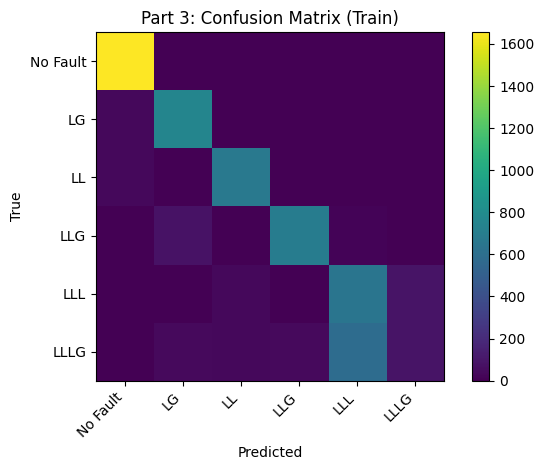


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9505    1.0000    0.9746       710
          LG     0.8466    0.9440    0.8926       339
          LL     0.9105    0.9468    0.9283       301
         LLG     0.9595    0.8353    0.8931       340
         LLL     0.5028    0.8116    0.6209       329
        LLLG     0.5000    0.1382    0.2166       340

    accuracy                         0.8109      2359
   macro avg     0.7783    0.7793    0.7544      2359
weighted avg     0.8044    0.8109    0.7866      2359



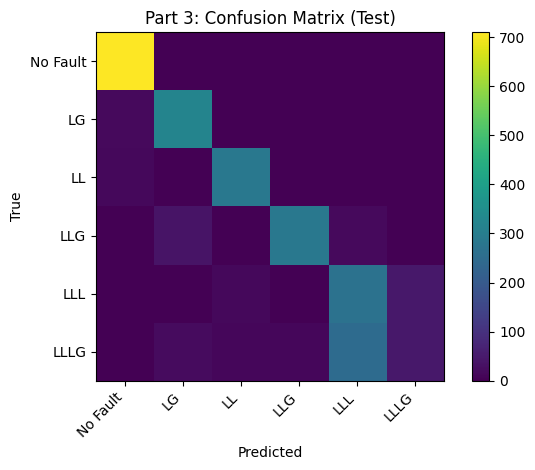

In [26]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?



2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?



3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: Multi-class fits the dataset best. This model achieves an 81% test accuracy with meaningful precision/recall across most classes. Furthermore, CrossEntropyLoss assumes there's exactly one correct class per sample. In comparison to this, the regression and multi-label models approach outputs as indpendent values or bits, which do not reflect the mutual exclusivity of the fault classes.

- Q2: Yes. From Part 3, we know there are 6 valid fault types. However, Model 1's confusion matrix has 11 columns. This means that only columns 0 -> 5 are valid faults, whilst 6 -> 10 are invalid decoded patterns. For model 2, we see that most predictions collapse into one column because many samples are mapped to the same bit pattern.

- Q3: Looking at the confusion matrix from part 3, we see that LLLG has an extremely low recall and f1 score in comparison to the other fault types. This likely occured due to overlapping feature patterns with other multi-line faults, making it difficult to distinguish.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [33]:
y_binary = (y_fault != 0).astype(int)

# Train/test split (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(
  X, y_binary,
  test_size=0.3,
  stratify=y_binary,
  random_state=42
)

# RobustScaler git on train
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# PyTorch dataset and loader
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = TensorDataset(
  torch.from_numpy(X_train_s).float(),
  torch.from_numpy(y_train).float().unsqueeze(1)
)

test_ds = TensorDataset(
  torch.from_numpy(X_test_s).float(),
  torch.from_numpy(y_test).float().unsqueeze(1)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

# Model
class DNN_BinaryFault(nn.Module):
  def __init__(self, input_dim=INPUT_DIM, p_drop=0.25):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(input_dim, 16),
      nn.BatchNorm1d(16),
      nn.ReLU(),
      nn.Dropout(p_drop),

      nn.Linear(16, 8),
      nn.BatchNorm1d(8),
      nn.ReLU(),
      nn.Dropout(p_drop),

      nn.Linear(8,1)
    )

  def forward(self, x):
    return self.net(x)

# Loss, optimizer
model = DNN_BinaryFault(X_train_s.shape[1]).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training loop
def train_binary(model, loader, epochs=30):
  model.train()
  for ep in range(1, epochs + 1):
    total_loss, total_n = 0.0, 0

    for xb, yb in loader:
      xb, yb = xb.to(device), yb.to(device)
      optimizer.zero_grad()
      logits = model(xb)
      loss = loss_fn(logits, yb)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * xb.size(0)
      total_n += xb.size(0)

    if ep in [1, epochs//2, epochs]:
      print (f"Epoch {ep:3d} | avg loss: {total_loss / total_n:.6f}")

train_binary(model, train_loader)

# Classification report & confusion matrix
@torch.no_grad()
def evaluate_binary(model, X_s, y_true):
  model.eval()
  X_t = torch.from_numpy(X_s).float().to(device)
  logits = model(X_t)
  probs = torch.sigmoid(logits).cpu().numpy().ravel()
  preds = (probs >= 0.5).astype(int)

  print(classification_report(y_true, preds, target_names=["No Fault", "Fault"]))
  print(confusion_matrix(y_true, preds))

print("=== Train ===")
evaluate_binary(model, X_train_s, y_train)
print("=== Test ===")
evaluate_binary(model, X_test_s, y_test)

Epoch   1 | avg loss: 0.568372
Epoch  15 | avg loss: 0.168801
Epoch  30 | avg loss: 0.140243
=== Train ===
              precision    recall  f1-score   support

    No Fault       0.90      1.00      0.95      1655
       Fault       1.00      0.95      0.98      3847

    accuracy                           0.97      5502
   macro avg       0.95      0.98      0.96      5502
weighted avg       0.97      0.97      0.97      5502

[[1655    0]
 [ 180 3667]]
=== Test ===
              precision    recall  f1-score   support

    No Fault       0.92      1.00      0.96       710
       Fault       1.00      0.96      0.98      1649

    accuracy                           0.97      2359
   macro avg       0.96      0.98      0.97      2359
weighted avg       0.98      0.97      0.97      2359

[[ 710    0]
 [  64 1585]]
